In [16]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

In [17]:
df = pd.read_csv("NIFTY_TCS.csv")

In [18]:
print(df.head())

         Date Symbol Series  Prev Close    Open    High     Low    Last  \
0  2004-08-25    TCS     EQ      850.00  1198.7  1198.7  979.00  985.00   
1  2004-08-26    TCS     EQ      987.95   992.0   997.0  975.30  976.85   
2  2004-08-27    TCS     EQ      979.00   982.4   982.4  958.55  961.20   
3  2004-08-30    TCS     EQ      962.65   969.9   990.0  965.00  986.40   
4  2004-08-31    TCS     EQ      986.75   986.5   990.0  976.00  987.80   

    Close     VWAP    Volume      Turnover  Trades  Deliverable Volume  \
0  987.95  1008.32  17116372  1.725876e+15     NaN             5206360   
1  979.00   985.65   5055400  4.982865e+14     NaN             1294899   
2  962.65   969.94   3830750  3.715586e+14     NaN              976527   
3  986.75   982.65   3058151  3.005106e+14     NaN              701664   
4  988.10   982.18   2649332  2.602133e+14     NaN              695234   

   %Deliverble  
0       0.3042  
1       0.2561  
2       0.2549  
3       0.2294  
4       0.2624  


In [19]:
df['Date'] = pd.to_datetime(df['Date'])

Text(0, 0.5, 'Close Price')

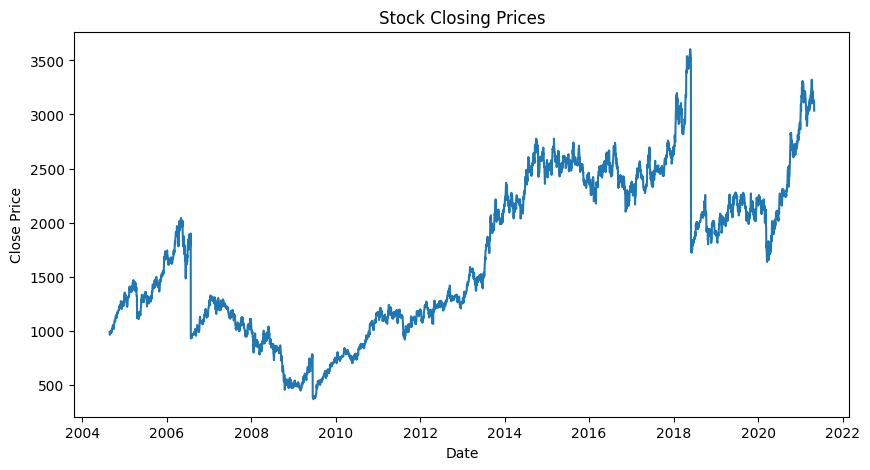

In [20]:
# Visualize Stock Prices

plt.figure(figsize=(10,5))

plt.plot(df['Date'], df['Close'])

plt.title("Stock Closing Prices")

plt.xlabel("Date")
plt.ylabel("Close Price")


In [21]:
# Create Feature and Target

# Use index as time feature
df['Day'] = np.arange(len(df))

X = df[['Day']]
y = df['Close']

In [22]:
# Chronological Train-Test Split

split_index = int(len(df) * 0.8)

X_train = X[:split_index]
X_test = X[split_index:]

y_train = y[:split_index]
y_test = y[split_index:]

In [23]:
# Train Linear Regression Model

model = LinearRegression()

model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [24]:
# Predictions

predictions = model.predict(X_test)

In [25]:
# Model Evaluation

mse = mean_squared_error(y_test, predictions)

print("Mean Squared Error:", mse)

Mean Squared Error: 278270.493338287


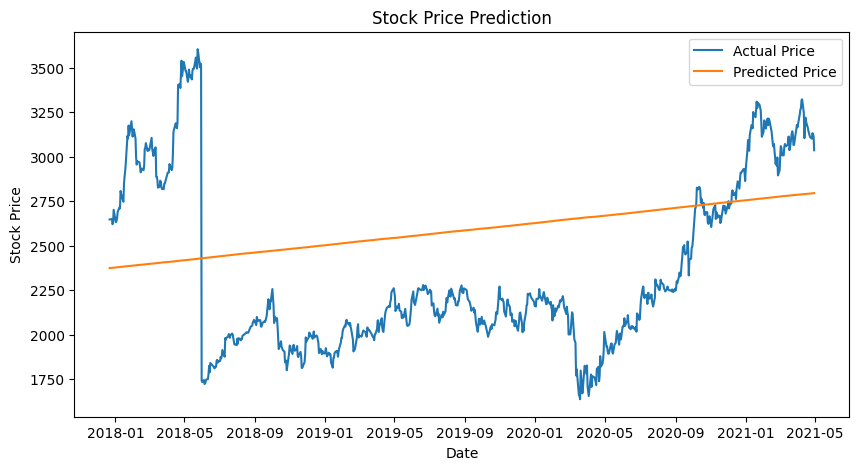

In [26]:
# Plot Actual vs Predicted

plt.figure(figsize=(10,5))

plt.plot(
    df['Date'][split_index:],
    y_test,
    label='Actual Price'
)

plt.plot(
    df['Date'][split_index:],
    predictions,
    label='Predicted Price'
)

plt.title("Stock Price Prediction")

plt.xlabel("Date")
plt.ylabel("Stock Price")
plt.legend()

plt.show()


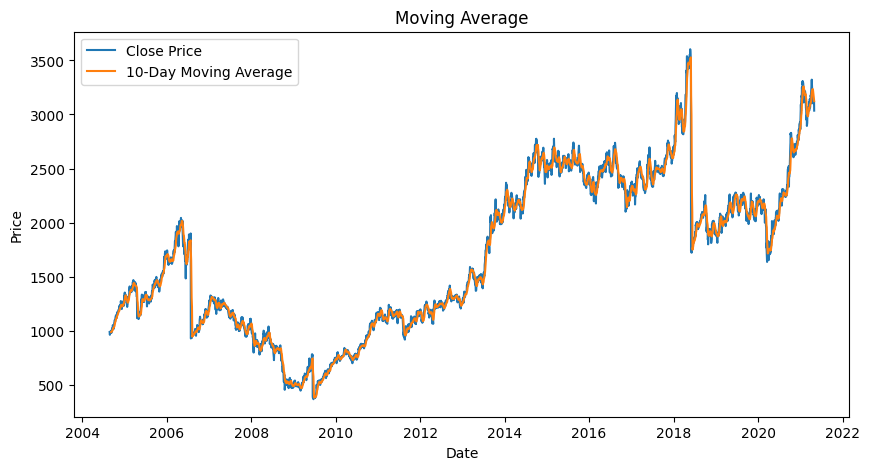

In [27]:
# Moving Average (Optional)

df['Moving_Avg_10'] = df['Close'].rolling(window=10).mean()

plt.figure(figsize=(10,5))

plt.plot(df['Date'], df['Close'], label='Close Price')

plt.plot(
    df['Date'],
    df['Moving_Avg_10'],
    label='10-Day Moving Average'
)

plt.title("Moving Average")

plt.xlabel("Date")
plt.ylabel("Price")

plt.legend()

plt.show()

In [28]:
'''
Final Outcome
  Loaded and visualized stock time series data
  Performed chronological train-test split
  Predicted stock prices using Linear Regression
  Understood Moving Averages
  Learned basics of Time Series Forecasting
'''

'\nFinal Outcome\n  Loaded and visualized stock time series data\n  Performed chronological train-test split\n  Predicted stock prices using Linear Regression\n  Understood Moving Averages\n  Learned basics of Time Series Forecasting\n'